     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 105.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f45fc6f0f77bf1960522dfa9939255ebf9d65bac693b41a2d945a69a78953e46
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Kullanılan Cihaz: cuda
Sınıflar: ['Gerd', 'Gerd Normal', 'Polyp', 'Polyp Normal']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 190MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 232MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 225MB/s]


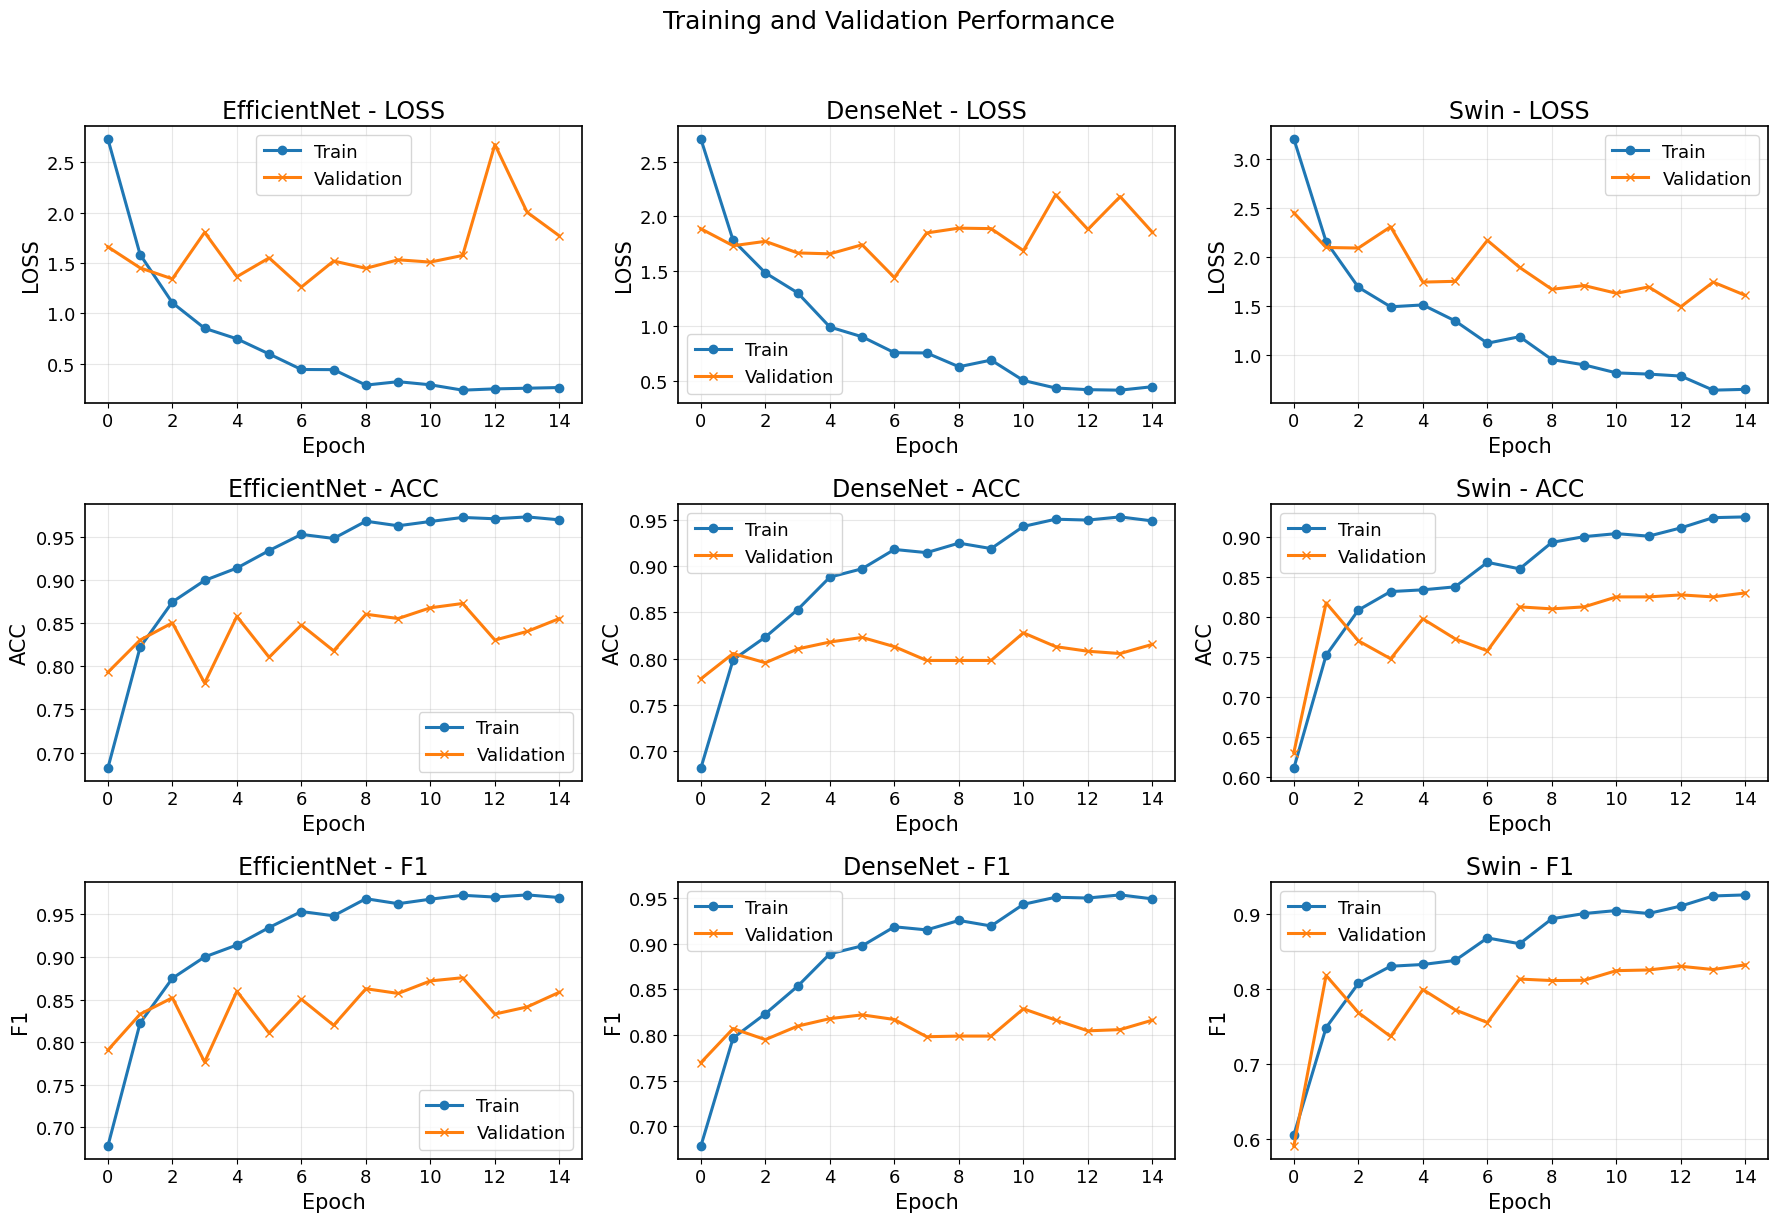

Ensemble ağırlıkları Validation seti üzerinden optimize ediliyor...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T


Bulunan Optimal Ağırlıklar:
EfficientNet: 0.5842
DenseNet:     0.1972
Swin:         0.2186

Test seti üzerinden nihai tahminler alınıyor...

EFFICIENTNET REPORT
              precision    recall  f1-score   support

        Gerd       0.89      0.71      0.79        98
 Gerd Normal       0.79      0.84      0.81       110
       Polyp       0.93      0.91      0.92        78
Polyp Normal       0.83      0.93      0.88       115

    accuracy                           0.85       401
   macro avg       0.86      0.85      0.85       401
weighted avg       0.85      0.85      0.85       401


DENSENET REPORT
              precision    recall  f1-score   support

        Gerd       0.84      0.81      0.82        98
 Gerd Normal       0.83      0.78      0.80       110
       Polyp       0.80      0.94      0.86        78
Polyp Normal       0.88      0.86      0.87       115

    accuracy                           0.84       401
   macro avg       0.84      0.85      0.84       401
weight

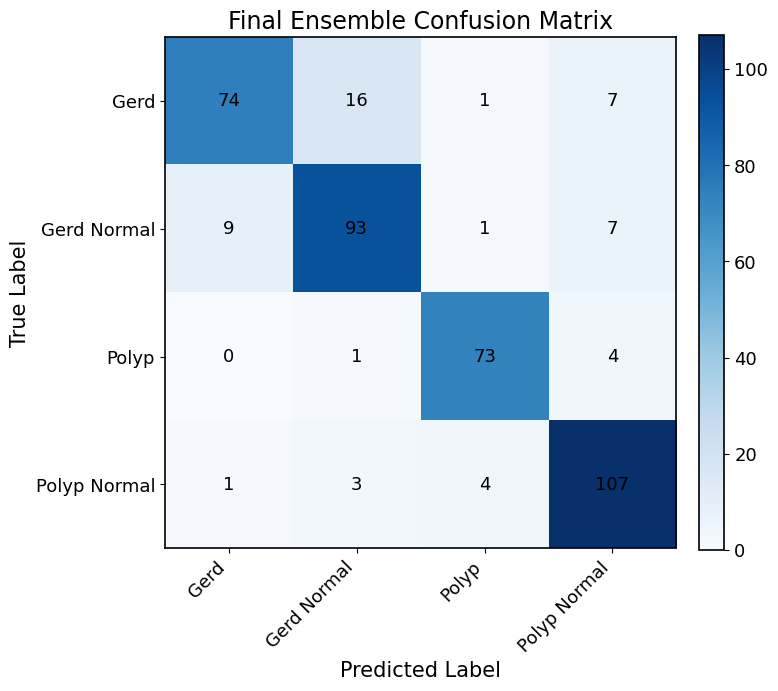

----------------------------------------
MACRO METRICS
Precision: 0.8710
Recall:    0.8667
F1-Score:  0.8672
----------------------------------------


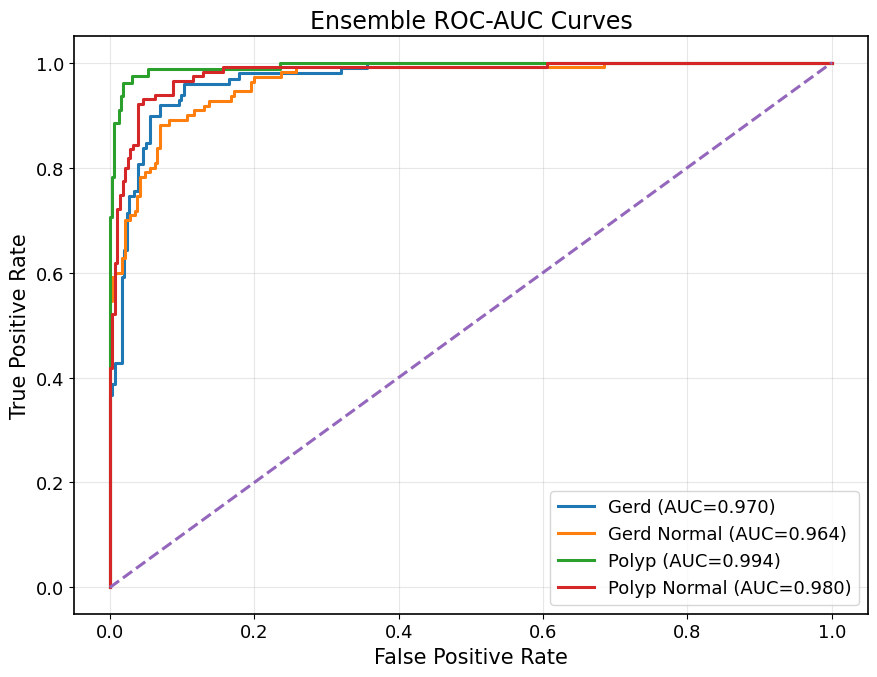

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
from tqdm import tqdm
from IPython.display import FileLink, display
!pip install grad-cam
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torch.optim import AdamW
from torchvision import datasets, transforms, models
from scipy.optimize import minimize
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

# ==========================================
# 1. KONFİGÜRASYON VE SEED
# ==========================================
mpl.rcParams.update({
    "font.size": 14, "axes.titlesize": 17, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 13,
    "figure.titlesize": 18, "axes.linewidth": 1.2, "lines.linewidth": 2.2,
    "svg.fonttype": "none",
})

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 4 # Gerd, Gerd Normal, Polyp, Polyp Normal

# Kendi veri setinin yolunu buraya gir (Görseldeki klasör yapısına göre)
DATA_DIR = "/kaggle/input/datasets/kevsergneli/gerd-and-polyp-dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Kullanılan Cihaz: {DEVICE}")

# ==========================================
# 2. VERİ SETİ VE TRANSFORMER (Sınıf Bazlı Augmentation Çıkarıldı)
# ==========================================
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Veri setini transform olmadan sadece indeks ve hedefleri almak için yüklüyoruz
temp_ds = datasets.ImageFolder(DATA_DIR)
targets = np.array(temp_ds.targets)
class_names = temp_ds.classes
print(f"Sınıflar: {class_names}")

# Indeksleri Ayırma (Train: %80, Val: %10, Test: %10)
train_idx, temp_idx = train_test_split(np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=targets[temp_idx], random_state=SEED)

# Farklı transformlar uygulayabilmek için ana veri setlerini iki kez tanımlıyoruz
ds_train = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
ds_val_test = datasets.ImageFolder(DATA_DIR, transform=val_tfms)

# Subset'leri oluşturma
train_dataset = Subset(ds_train, train_idx)
val_dataset = Subset(ds_val_test, val_idx)
test_dataset = Subset(ds_val_test, test_idx)

# DataLoader'lar
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Sınıf Ağırlıkları Hesaplama (Focal Loss için)
class_weights = torch.tensor([len(train_idx) / Counter(targets[train_idx])[i] for i in range(NUM_CLASSES)], dtype=torch.float).to(DEVICE)

# ==========================================
# 3. KAYIP (LOSS) VE YARDIMCI FONKSİYONLAR
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

def fit_model(model, name, epochs=15):
    opt = AdamW(model.parameters(), lr=2e-4)
    crit = FocalLoss(alpha=class_weights)
    hist = {"tr_loss":[], "val_loss":[], "tr_acc":[], "val_acc":[], "tr_f1":[], "val_f1":[]}
    best_f1 = 0
    
    for epoch in range(epochs):
        model.train()
        t_y, t_p, t_losses = [], [], []
        
        for x, y in tqdm(train_loader, desc=f"{name} Ep {epoch+1}", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            
            t_losses.append(loss.item())
            t_y.extend(y.cpu().numpy())
            t_p.extend(out.argmax(1).cpu().numpy())
            
        model.eval()
        v_y, v_p, v_losses = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                v_losses.append(crit(out, y).item())
                v_y.extend(y.cpu().numpy())
                v_p.extend(out.argmax(1).cpu().numpy())
        
        hist["tr_loss"].append(np.mean(t_losses))
        hist["val_loss"].append(np.mean(v_losses))
        hist["tr_acc"].append(accuracy_score(t_y, t_p))
        hist["val_acc"].append(accuracy_score(v_y, v_p))
        hist["tr_f1"].append(f1_score(t_y, t_p, average="macro"))
        hist["val_f1"].append(f1_score(v_y, v_p, average="macro"))
        
        if hist["val_f1"][-1] > best_f1:
            best_f1 = hist["val_f1"][-1]
            torch.save(model.state_dict(), f"best_{name}.pth")
            
    return best_f1, hist

# ==========================================
# 4. MODEL KURUCULARI
# ==========================================
def build_effnet(dropout=0.3):
    m = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
    m.classifier[1] = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m.to(DEVICE)

def build_densenet(dropout=0.3):
    m = models.densenet121(weights='IMAGENET1K_V1')
    m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.classifier.in_features, NUM_CLASSES))
    return m.to(DEVICE)

def build_swin(dropout=0.3):
    m = models.swin_t(weights='IMAGENET1K_V1')
    m.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.head.in_features, NUM_CLASSES))
    return m.to(DEVICE)

# ==========================================
# 5. EĞİTİM İCRA VE EĞRİLERİ ÇİZME
# ==========================================
_, h_eff = fit_model(build_effnet(), "effnet", epochs=15)
_, h_den = fit_model(build_densenet(), "densenet", epochs=15)
_, h_swin = fit_model(build_swin(), "swin", epochs=15)

def plot_advanced_history(histories, model_names, save=True):
    metrics = ['loss', 'acc', 'f1']
    fig, axes = plt.subplots(len(metrics), len(histories), figsize=(18, 12))

    for i, (name, hist) in enumerate(zip(model_names, histories)):
        for j, metric in enumerate(metrics):
            ax = axes[j, i]
            ax.plot(hist[f"tr_{metric}"], label='Train', marker='o')
            ax.plot(hist[f"val_{metric}"], label='Validation', marker='x')
            ax.set_title(f"{name} - {metric.upper()}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(metric.upper())
            ax.legend()
            ax.grid(alpha=0.3)

    fig.suptitle("Training and Validation Performance", y=1.02)
    plt.tight_layout()
    if save:
        plt.savefig("gerd_polyp_training_curves.svg", format="svg", bbox_inches="tight")
    plt.show()

plot_advanced_history([h_eff, h_den, h_swin], ["EfficientNet", "DenseNet", "Swin"])

# ==========================================
# 6. ENSEMBLE VE FINAL DEĞERLENDİRME (TEST SETİ ÜZERİNDE)
# ==========================================

@torch.no_grad()
def get_probs(model_builder, weight_path, loader):
    model = model_builder(dropout=0.0)
    model.load_state_dict(torch.load(weight_path))
    model.eval()
    probs, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        probs.append(torch.softmax(model(x), 1).cpu().numpy())
        labels.extend(y.numpy())
    return np.vstack(probs), np.array(labels)

# --- Ağırlık Optimizasyonu Fonksiyonları ---
def objective_function(weights, preds, true_labels):
    # Olasılıkların ağırlıklı ortalamasını al
    blended_probs = (preds[0] * weights[0]) + (preds[1] * weights[1]) + (preds[2] * weights[2])
    # Optimizasyon algoritmasının minimize etmeye çalışacağı Log Loss değeri
    return log_loss(true_labels, blended_probs)

def optimize_ensemble_weights(p1, p2, p3, y_true):
    preds = [p1, p2, p3]
    num_models = len(preds)
    initial_weights = [1.0 / num_models] * num_models # Başlangıç: [0.33, 0.33, 0.33]
    bounds = [(0.0, 1.0)] * num_models # Ağırlıklar 0 ile 1 arasında olmalı
    constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)}) # Ağırlıkların toplamı 1 olmalı
    
    result = minimize(
        objective_function, 
        initial_weights, 
        args=(preds, y_true), 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints
    )
    return result.x

def get_optimized_probs(p1, p2, p3, weights):
    return (p1 * weights[0]) + (p2 * weights[1]) + (p3 * weights[2])

# --- 1. Ağırlıkları Doğrulama (Validation) Seti ile Optimize Et ---
print("Ensemble ağırlıkları Validation seti üzerinden optimize ediliyor...")
p1_val, y_val_true = get_probs(build_effnet, "best_effnet.pth", val_loader)
p2_val, _ = get_probs(build_densenet, "best_densenet.pth", val_loader)
p3_val, _ = get_probs(build_swin, "best_swin.pth", val_loader)

opt_weights = optimize_ensemble_weights(p1_val, p2_val, p3_val, y_val_true)

print(f"\nBulunan Optimal Ağırlıklar:")
print(f"EfficientNet: {opt_weights[0]:.4f}")
print(f"DenseNet:     {opt_weights[1]:.4f}")
print(f"Swin:         {opt_weights[2]:.4f}\n")

# --- 2. Nihai Tahminleri Test Seti Üzerinden Al ---
print("Test seti üzerinden nihai tahminler alınıyor...")
p1_test, y_true_test = get_probs(build_effnet, "best_effnet.pth", test_loader)
p2_test, _ = get_probs(build_densenet, "best_densenet.pth", test_loader)
p3_test, _ = get_probs(build_swin, "best_swin.pth", test_loader)

y_probs_final = get_optimized_probs(p1_test, p2_test, p3_test, opt_weights)
y_pred = y_probs_final.argmax(axis=1)
y_eff_pred = p1_test.argmax(axis=1)
y_den_pred = p2_test.argmax(axis=1)
y_swin_pred = p3_test.argmax(axis=1)

print("\n" + "="*40)
print("EFFICIENTNET REPORT")
print("="*40)
print(classification_report(y_true_test, y_eff_pred, target_names=class_names))

print("\n" + "="*40)
print("DENSENET REPORT")
print("="*40)
print(classification_report(y_true_test, y_den_pred, target_names=class_names))

print("\n" + "="*40)
print("SWIN TRANSFORMER REPORT")
print("="*40)
print(classification_report(y_true_test, y_swin_pred, target_names=class_names))
# --- Raporlama ---
print("\n" + "="*40 + "\nFİNAL ENSEMBLE RAPORU\n" + "="*40)
print(classification_report(y_true_test, y_pred, target_names=class_names))
def quick_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}")

print("\nMODEL KARŞILAŞTIRMA")
quick_metrics(y_true_test, y_eff_pred, "EfficientNet")
quick_metrics(y_true_test, y_den_pred, "DenseNet")
quick_metrics(y_true_test, y_swin_pred, "Swin")
quick_metrics(y_true_test, y_pred, "Ensemble")
# --- Confusion Matrix Görselleştirme ---
def plot_confusion_svg(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Final Ensemble Confusion Matrix")

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig("gerd_polyp_confusion_matrix.svg", format="svg", bbox_inches="tight")
    plt.show()

plot_confusion_svg(y_true_test, y_pred, class_names)

# --- ROC Eğrileri Görselleştirme ---
def final_deep_analysis(y_true, y_probs, class_names):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_probs.argmax(axis=1), average='macro')
    print("-" * 40 + "\nMACRO METRICS")
    print(f"Precision: {precision:.4f}\nRecall:    {recall:.4f}\nF1-Score:  {f1:.4f}\n" + "-" * 40)

    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    fig = plt.figure(figsize=(9, 7))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Ensemble ROC-AUC Curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("gerd_polyp_roc_curves.svg", format="svg", bbox_inches="tight")
    plt.show()

final_deep_analysis(y_true_test, y_probs_final, class_names)

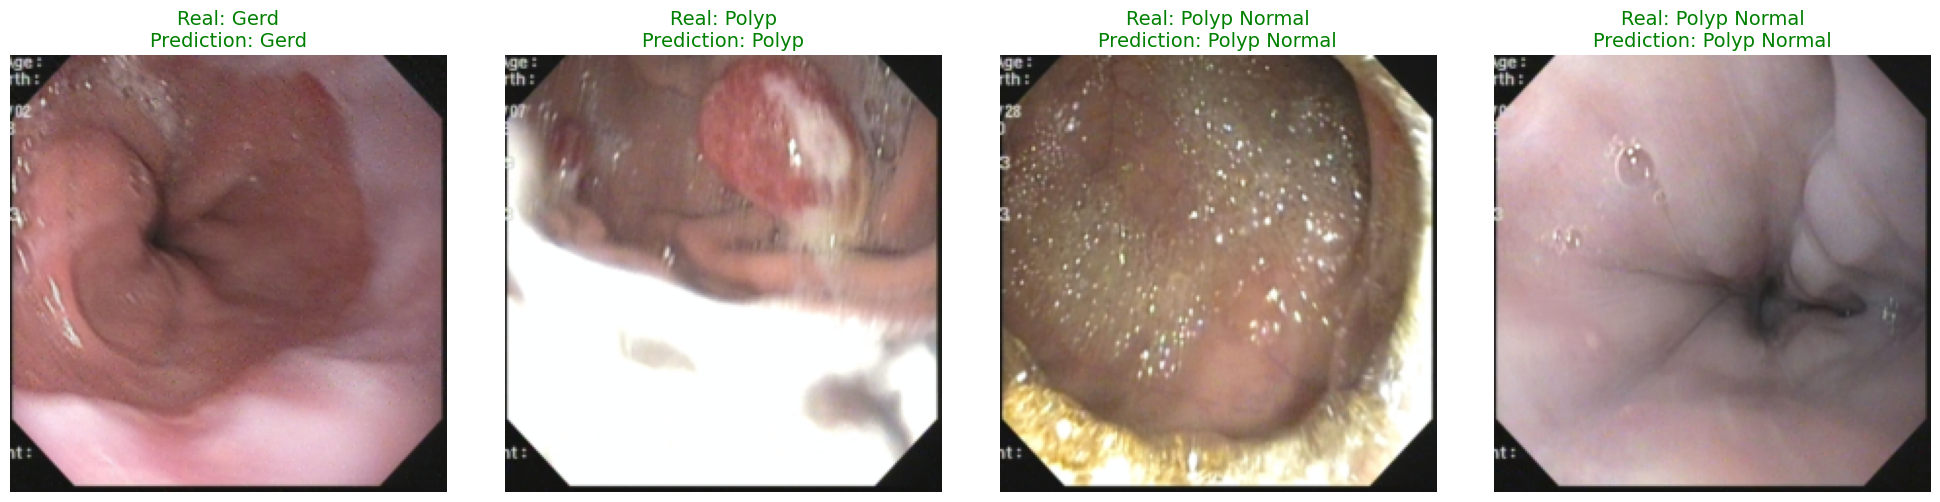

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Görselleri normalizasyondan geri çevirmek için yardımcı fonksiyon
def unnormalize_img(tensor):
    img = tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np = np.array([0.229, 0.224, 0.225])
    img = std_np * img + mean_np
    return np.clip(img, 0, 1)

# Modelleri tekrar belleğe alıyoruz
m_eff = build_effnet(dropout=0.0).to(DEVICE)
m_eff.load_state_dict(torch.load("best_effnet.pth"))
m_eff.eval()

m_den = build_densenet(dropout=0.0).to(DEVICE)
m_den.load_state_dict(torch.load("best_densenet.pth"))
m_den.eval()

m_swin = build_swin(dropout=0.0).to(DEVICE)
m_swin.load_state_dict(torch.load("best_swin.pth"))
m_swin.eval()

correct_samples = []
incorrect_samples = []

# Tahminleri toplayıp doğru ve yanlışları ayırma
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        
        # Ensemble ihtimallerini optimize edilmiş ağırlıklarla hesaplama
        out_eff = F.softmax(m_eff(x), dim=1)
        out_den = F.softmax(m_den(x), dim=1)
        out_swin = F.softmax(m_swin(x), dim=1)
        
        combined = (out_eff * opt_weights[0]) + (out_den * opt_weights[1]) + (out_swin * opt_weights[2])
        preds = combined.argmax(1).cpu().numpy()
        labels_np = y.numpy()
        
        for i in range(len(labels_np)):
            is_correct = (preds[i] == labels_np[i])
            
            sample = {
                'tensor': x[i].unsqueeze(0),
                'image': unnormalize_img(x[i]),
                'true_label': class_names[labels_np[i]],
                'pred_label': class_names[preds[i]],
                'true_idx': labels_np[i]
            }
            
            if is_correct and len(correct_samples) < 4:
                correct_samples.append(sample)
            elif not is_correct and len(incorrect_samples) < 4:
                incorrect_samples.append(sample)
                
        # İkisinden de 4'er tane bulduysak döngüyü kır
        if len(correct_samples) == 4 and len(incorrect_samples) == 4:
            break

# =========================================
# GÖRSELLEŞTİRME 1: DOĞRU TAHMİNLER
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, sample in enumerate(correct_samples):
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"Real: {sample['true_label']}\nPrediction: {sample['pred_label']}", color="green", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("gerd_polyp_correct_preds.svg", format="svg", bbox_inches="tight")
plt.show()

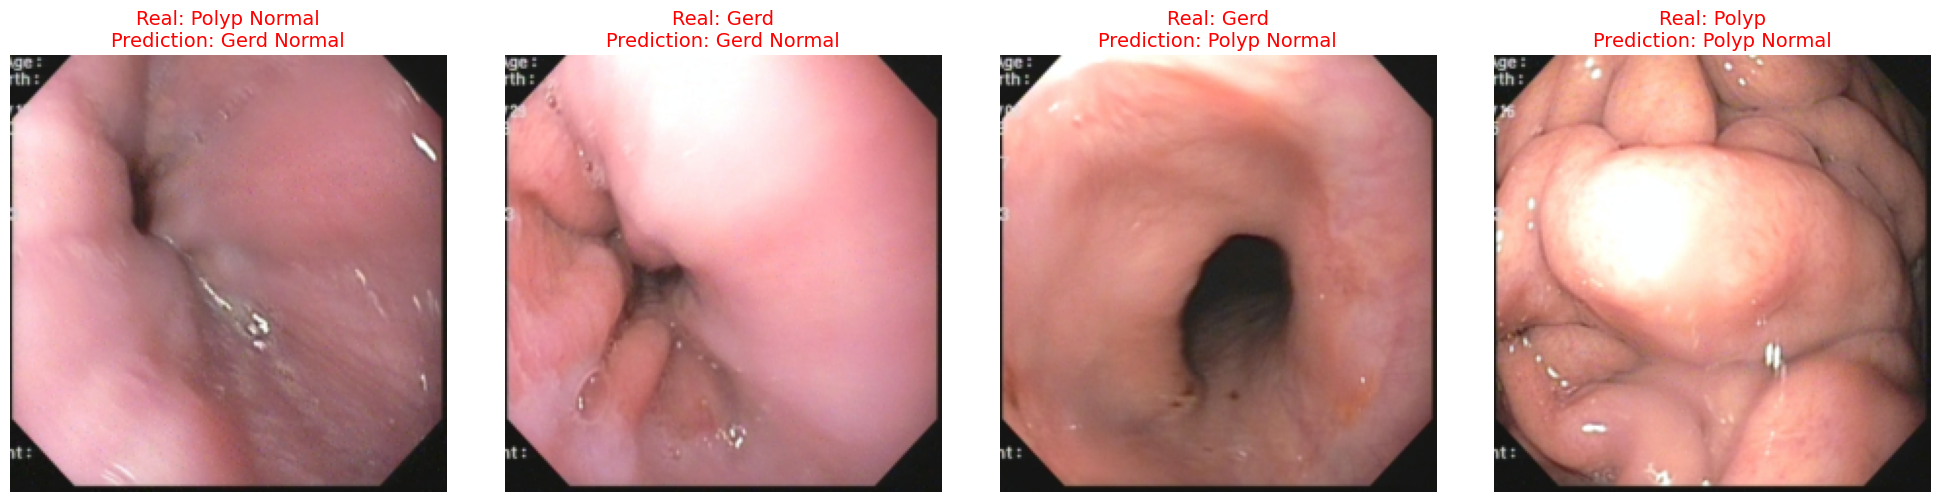

In [3]:
# =========================================
# GÖRSELLEŞTİRME 2: YANLIŞ TAHMİNLER
# =========================================
num_incorrect = len(incorrect_samples)

if num_incorrect == 0:
    print("Harika! Ensemble modeliniz bu batch/test seti üzerinde hiç hata yapmadı.")
else:
    fig, axes = plt.subplots(1, num_incorrect, figsize=(5 * num_incorrect, 5))
    
    if num_incorrect == 1:
        axes = [axes]
        
    for i, sample in enumerate(incorrect_samples):
        axes[i].imshow(sample['image'])
        axes[i].set_title(f"Real: {sample['true_label']}\nPrediction: {sample['pred_label']}", color="red", fontsize=14)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("gerd_polyp_incorrect_preds.svg", format="svg", bbox_inches="tight")
    plt.show()

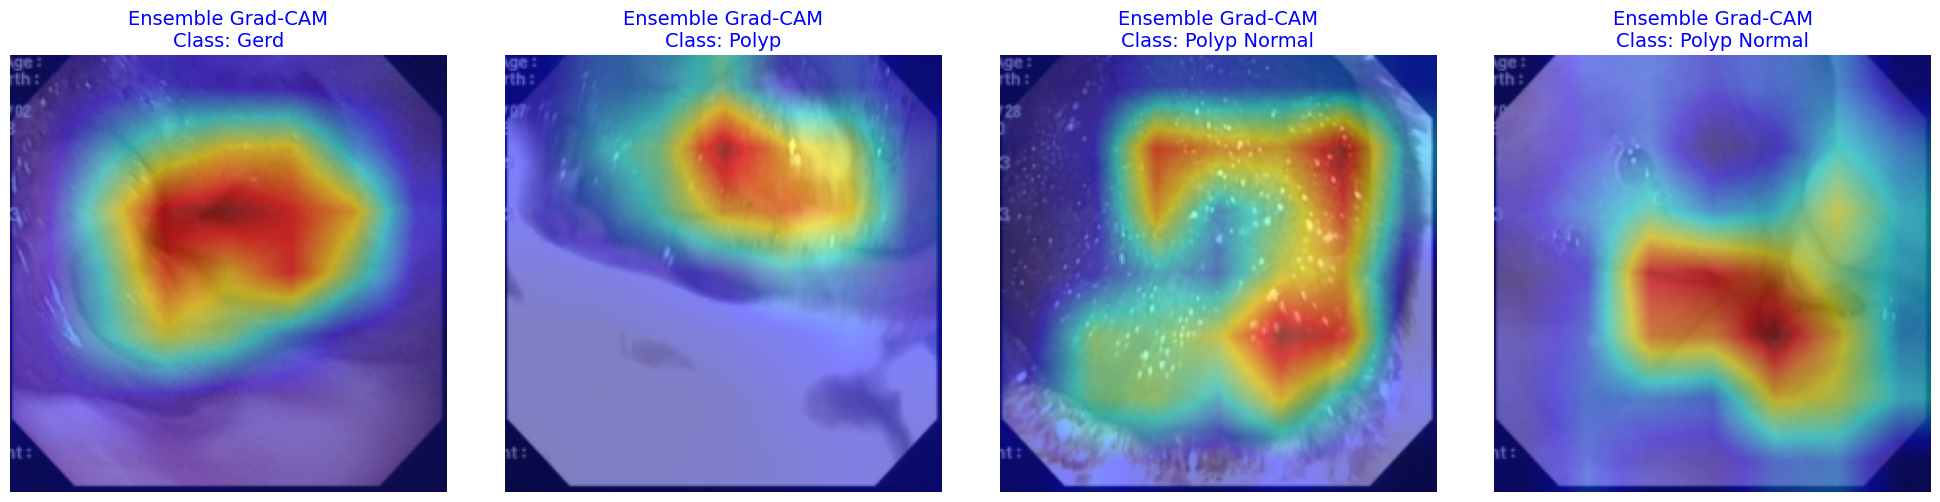

In [4]:
# =========================================
# GÖRSELLEŞTİRME 3: META MODEL (ENSEMBLE) GRAD-CAM
# =========================================

# Swin Transformer'ın tensör çıktısını (B, H, W, C) Grad-CAM'in beklediği (B, C, H, W) formatına çeviren fonksiyon
def reshape_transform_swin(tensor):
    return tensor.permute(0, 3, 1, 2)

# 1. Her model için kendi mimarisine uygun Grad-CAM nesnelerini oluştur
cam_eff = GradCAM(model=m_eff, target_layers=[m_eff.features[-1]])
cam_den = GradCAM(model=m_den, target_layers=[m_den.features[-1]])
cam_swin = GradCAM(model=m_swin, 
                   target_layers=[m_swin.features[-1][-1]], 
                   reshape_transform=reshape_transform_swin)

fig, axes = plt.subplots(1, len(correct_samples), figsize=(20, 5))

# Tek bir örnek gelme ihtimaline karşı axes'i listeye çevir
if len(correct_samples) == 1:
    axes = [axes]

for i, sample in enumerate(correct_samples):
    input_tensor = sample['tensor']
    target_class_idx = sample['true_idx']
    
    # Doğru bilinen sınıf hedefleniyor
    targets = [ClassifierOutputTarget(target_class_idx)]
    
    # 2. Her modelin kendi ısı haritasını hesapla
    map_eff = cam_eff(input_tensor=input_tensor, targets=targets)[0, :]
    map_den = cam_den(input_tensor=input_tensor, targets=targets)[0, :]
    map_swin = cam_swin(input_tensor=input_tensor, targets=targets)[0, :]
    
    # 3. Meta Model Isı Haritası (Optimal ağırlıklarla birleştirme)
    cam_ensemble = (map_eff * opt_weights[0]) + (map_den * opt_weights[1]) + (map_swin * opt_weights[2])
    
    # Görselin soluk olmaması için Min-Max Normalizasyonu (0 ile 1 arasına çekme)
    cam_ensemble = (cam_ensemble - np.min(cam_ensemble)) / (np.max(cam_ensemble) - np.min(cam_ensemble) + 1e-8)
    
    # Isı haritasını orijinal resmin üzerine bindir
    cam_image = show_cam_on_image(sample['image'], cam_ensemble, use_rgb=True)
    
    axes[i].imshow(cam_image)
    axes[i].set_title(f"Ensemble Grad-CAM\nClass: {sample['true_label']}", color="blue", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("gerd_polyp_ensemble_gradcam.svg", format="svg", bbox_inches="tight")
plt.show()